node degree clustering
0 1 0
1 4 0
2 2 0
3 4 0
4 4 0.3333333333333333
5 3 0.3333333333333333
6 4 0
7 6 0.4
8 4 0.3333333333333333
9 1 0
10 7 0.23809523809523808
11 5 0
12 5 0
13 8 0.21428571428571427
14 2 0
15 6 0.13333333333333333
16 2 0
17 4 0.3333333333333333
18 4 0.3333333333333333
19 4 0.3333333333333333

the adjacency list
0 3
1 2 17 12 3
2 11
3 13 11
4 18 15 19 13
5 15 7 19
6 15 8 16 12
7 10 19 13 17 8
8 10 17
9 11
10 11 13 19 15 18
11 12
12 18 14
13 16 17 18 15
14 15
15
16
17
18
19


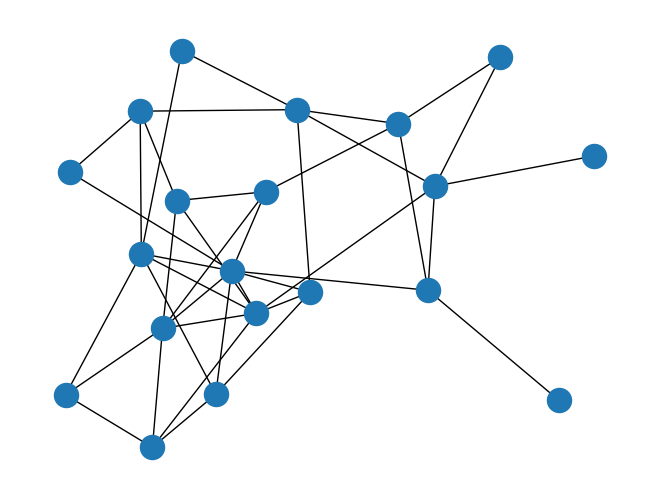

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

n = 20  # 10 nodes
m = 40  # 20 edges
seed = 20160  # seed random number generators for reproducibility

# Use seed for reproducibility
# G = nx.gnm_random_graph(n, m, seed=seed)

G = nx.gnm_random_graph(n, m)

# some properties
print("node degree clustering")
for v in nx.nodes(G):
    print(f"{v} {nx.degree(G, v)} {nx.clustering(G, v)}")

print()
print("the adjacency list")
for line in nx.generate_adjlist(G):
    print(line)

pos = nx.spring_layout(G, seed=seed)  # Seed for reproducible layout
nx.draw(G, pos=pos)
plt.show()

In [ ]:
def coloring_conflicts (G, coloring):
    conflicts = 0
    # Use the edge set to check for conflicts
    for u, v in G.edges():
        # print(f"edge ({u}, {v}) has colors {coloring[u]} and {coloring[v]}")
        if coloring[u] == coloring[v]:
            conflicts += 1
    return conflicts

## Testing out coloring using built in greedy algorithm

In [ ]:
def graph_coloring(G):
    # Use a greedy coloring algorithm
    coloring = nx.coloring.greedy_color(G, strategy='largest_first')
    return coloring

In [ ]:
coloring = graph_coloring(G)
node_colors = [coloring[node] for node in G.nodes()]
nx.draw(G, pos=pos, node_color=node_colors, with_labels=True)
plt.show() 

### Check for conflicts

In [ ]:
conflicts = coloring_conflicts(G, coloring)
conflicts

## Randomly assigning colors

In [ ]:

import random
      
def random_coloring(G):
    coloring = {}
    for node in G.nodes():
        coloring[node] = random.randint(0, n-1)  # Random color from 0 to n-1
    return coloring

In [ ]:
coloring = random_coloring(G)
node_colors = [coloring[node] for node in G.nodes()]
nx.draw(G, pos=pos, node_color=node_colors, with_labels=True)
plt.show()

In [ ]:
conflicts = coloring_conflicts(G, coloring)
print(f"Number of conflicts: {conflicts}")

In [ ]:
import numpy as np

list_of_conflicts = []
for i in range(200):
    multiple_coloring = random_coloring(G)
    node_colors = [coloring[node] for node in G.nodes()]
    conflicts = coloring_conflicts(G, multiple_coloring)
    list_of_conflicts.append(conflicts)
    print(f"Trial {i+1}: Number of conflicts: {conflicts}")


plt.figure(figsize=(12, 6))
plt.plot(list_of_conflicts)
plt.xlabel('Trial')
plt.ylabel('Number of Conflicts')
plt.title('Conflicts in Random Colorings of the Graph')
plt.xticks(range(0, 200, 10))

plt.show()

print(f"Average conflicts: {np.mean(list_of_conflicts):.2f}")


An average number of conflicts of 1.55 / 30 possible is really good odds for a random assignment of colors

In [ ]:
average_conflicts = []
trials = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
for i in range(len(trials)):
    list_of_conflicts = []
    for j in range(trials[i]):
        multiple_coloring = random_coloring(G)
        node_colors = [coloring[node] for node in G.nodes()]
        conflicts = coloring_conflicts(G, multiple_coloring)
        list_of_conflicts.append(conflicts)
    average_conflicts.append(np.mean(list_of_conflicts))
    print(f"For {trials[i]} trials : Average Number of conflicts: {average_conflicts[-1]:.2f}")


plt.figure(figsize=(12, 6))
plt.plot(trials, average_conflicts)
plt.xlabel('Trials')
plt.ylabel('Average Number of Conflicts')
plt.title('Conflicts in Random Colorings of the Graph')
plt.xticks(trials)

plt.show()


## Step 1 Assignment

node degree clustering
0 3 0
1 3 0.3333333333333333
2 6 0.06666666666666667
3 5 0.1
4 5 0.2
5 3 0
6 5 0.4
7 3 0
8 4 0.16666666666666666
9 1 0
10 6 0.2
11 4 0
12 4 0
13 1 0
14 3 0
15 5 0
16 5 0.2
17 3 0.3333333333333333
18 6 0.13333333333333333
19 5 0.3

the adjacency list
0 15 2 12
1 8 15 2
2 8 19 11 3
3 14 16 15 6
4 12 6 16 19 7
5 7 10 15
6 10 19 16
7 11
8 14 10
9 16
10 17 19 18
11 14 17
12 18 13
13
14
15 18
16 18
17 18
18 19
19


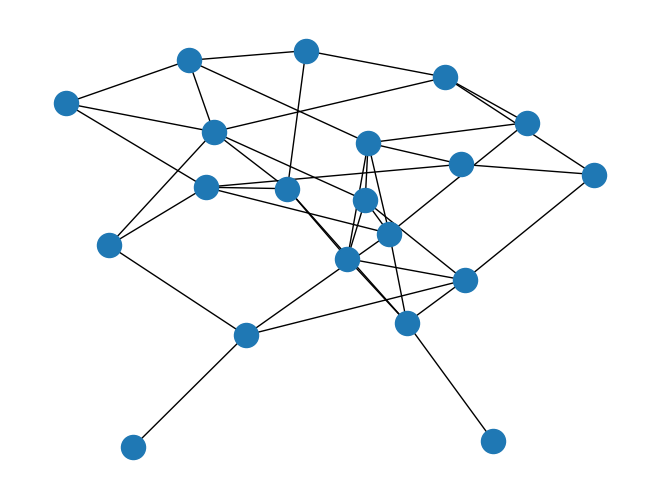

In [3]:
n = 20  # 10 nodes
m = 40  # 20 edges
seed = 20160  # seed random number generators for reproducibility

# Use seed for reproducibility
# G = nx.gnm_random_graph(n, m, seed=seed)

T = nx.gnm_random_graph(n, m)

# some properties
print("node degree clustering")
for v in nx.nodes(T):
    print(f"{v} {nx.degree(T, v)} {nx.clustering(T, v)}")

print()
print("the adjacency list")
for line in nx.generate_adjlist(T):
    print(line)

pos = nx.spring_layout(T, seed=seed)  # Seed for reproducible layout
nx.draw(T, pos=pos)
plt.show()

In [ ]:
for i in range(200):
    multiple_coloring = random_coloring(T)
    node_colors = [coloring[node] for node in T.nodes()]
    conflicts = coloring_conflicts(T, multiple_coloring)
    list_of_conflicts.append(conflicts)

nx.draw(T, pos=pos, node_color=node_colors, with_labels=True)
plt.show()

In [ ]:
def chromatic_optimiser(T) :
    for node in T.nodes():
        # Get the colors of the neighbors
        neighbor_colors = set(coloring[neighbor] for neighbor in T.neighbors(node))
        # Find the smallest color that is not used by the neighbors
        for color in range(n):
            if color not in neighbor_colors:
                coloring[node] = color
                break

In [ ]:
chromatic_optimiser(T)
node_colors = [coloring[node] for node in T.nodes()]
nx.draw(T, pos=pos, node_color=node_colors, with_labels=True)
plt.show()
print(f"Number of conflicts after optimization: {coloring_conflicts(T, coloring)}")
print(f"Chromatic number: {max(coloring.values()) + 1}")